# Fase 2 CRISP-DM — Data Understanding
## Análisis Exploratorio de Datos (EDA)
**Proyecto:** Customer Behavior Analysis — Olist Brazilian E-Commerce  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Objetivo:** Comprender la estructura, calidad y distribuciones del dataset antes de la preparación de datos.

---

## 0. Imports y configuración

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Rutas relativas desde notebooks/
ROOT = Path().resolve().parent
DB_PATH = ROOT / "data" / "olist.db"

# Estilo global
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print(f"DB path: data/{DB_PATH.name}")
print(f"DB exists: {DB_PATH.exists()}")

DB path: data/olist.db
DB exists: True


---
## 1. Carga de datos
Conectamos a `data/olist.db` y cargamos las 9 tablas en DataFrames de Pandas.  
La base de datos fue generada por `sql/load_data.py` a partir de los CSVs originales de Olist.

In [2]:
conn = sqlite3.connect(DB_PATH)

tables = {
    "orders":             "SELECT * FROM orders",
    "order_items":        "SELECT * FROM order_items",
    "order_payments":     "SELECT * FROM order_payments",
    "order_reviews":      "SELECT * FROM order_reviews",
    "customers":          "SELECT * FROM customers",
    "products":           "SELECT * FROM products",
    "sellers":            "SELECT * FROM sellers",
    "geolocation":        "SELECT * FROM geolocation",
    "category_translation": "SELECT * FROM category_translation",
}

dfs = {name: pd.read_sql(query, conn) for name, query in tables.items()}
conn.close()

for name, df in dfs.items():
    print(f"  {name:25s} {len(df):>10,} filas  {df.shape[1]:>3} columnas")

  orders                        99,441 filas    8 columnas
  order_items                  112,650 filas    7 columnas
  order_payments               103,886 filas    5 columnas
  order_reviews                 99,224 filas    7 columnas
  customers                     99,441 filas    5 columnas
  products                      32,951 filas    9 columnas
  sellers                        3,095 filas    4 columnas
  geolocation                1,000,163 filas    5 columnas
  category_translation              71 filas    2 columnas


---
## 2. Calidad de datos por tabla
Para cada tabla inspeccionamos:
- **Tipos de datos** de cada columna
- **Valores nulos** (count y porcentaje)
- **Filas duplicadas**

Esto nos permite identificar columnas problemáticas antes de la fase de preparación.

In [3]:
def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Genera un resumen de calidad para un DataFrame."""
    n = len(df)
    report = pd.DataFrame({
        "dtype":     df.dtypes,
        "nulls":     df.isnull().sum(),
        "null_pct":  (df.isnull().sum() / n * 100).round(2),
        "unique":    df.nunique(),
    })
    dups = df.duplicated().sum()
    print(f"\n{'='*55}")
    print(f"  Tabla: {name}  |  {n:,} filas  |  {dups:,} duplicados")
    print(f"{'='*55}")
    return report

quality_reports = {}
for name, df in dfs.items():
    quality_reports[name] = quality_report(df, name)
    display(quality_reports[name])


  Tabla: orders  |  99,441 filas  |  0 duplicados


,dtype,nulls,null_pct,unique
order_id,object,0,0.00,99441
customer_id,object,0,0.00,99441
order_status,object,0,0.00,8
order_purchase_timestamp,object,0,0.00,98875
order_approved_at,object,160,0.16,90733
order_delivered_carrier_date,object,1783,1.79,81018
order_delivered_customer_date,object,2965,2.98,95664
order_estimated_delivery_date,object,0,0.00,459



  Tabla: order_items  |  112,650 filas  |  0 duplicados


,dtype,nulls,null_pct,unique
order_id,object,0,0.0,98666
order_item_id,int64,0,0.0,21
product_id,object,0,0.0,32951
seller_id,object,0,0.0,3095
shipping_limit_date,object,0,0.0,93318
price,float64,0,0.0,5968
freight_value,float64,0,0.0,6999



  Tabla: order_payments  |  103,886 filas  |  0 duplicados


...

,dtype,nulls,null_pct,unique
seller_id,object,0,0.0,3095
seller_zip_code_prefix,int64,0,0.0,2246
seller_city,object,0,0.0,611
seller_state,object,0,0.0,23



  Tabla: geolocation  |  1,000,163 filas  |  261,831 duplicados


,dtype,nulls,null_pct,unique
geolocation_zip_code_prefix,int64,0,0.0,19015
geolocation_lat,float64,0,0.0,717360
geolocation_lng,float64,0,0.0,717613
geolocation_city,object,0,0.0,8011
geolocation_state,object,0,0.0,27



  Tabla: category_translation  |  71 filas  |  0 duplicados


,dtype,nulls,null_pct,unique
product_category_name,object,0,0.0,71
product_category_name_english,object,0,0.0,71


### Observaciones sobre calidad de datos

Las columnas con nulos relevantes que deberemos tratar en la Fase 3 son:

| Tabla | Columna | Motivo probable |
|-------|---------|----------------|
| `orders` | `order_approved_at` | Pedidos cancelados antes de aprobación |
| `orders` | `order_delivered_carrier_date` | Pedidos no enviados |
| `orders` | `order_delivered_customer_date` | Pedidos no entregados |
| `order_reviews` | `review_comment_title` / `review_comment_message` | Reseñas sin texto (solo puntuación) |
| `products` | `product_category_name` | Categorías no asignadas |

---
## 3. Distribuciones clave
Analizamos las variables más relevantes para el negocio.

### 3.1 Distribución de `review_score`
El score de satisfacción va de 1 a 5. Una distribución sesgada hacia valores extremos (1 o 5) es típica en reseñas de e-commerce — los clientes neutros suelen no dejar reseña.

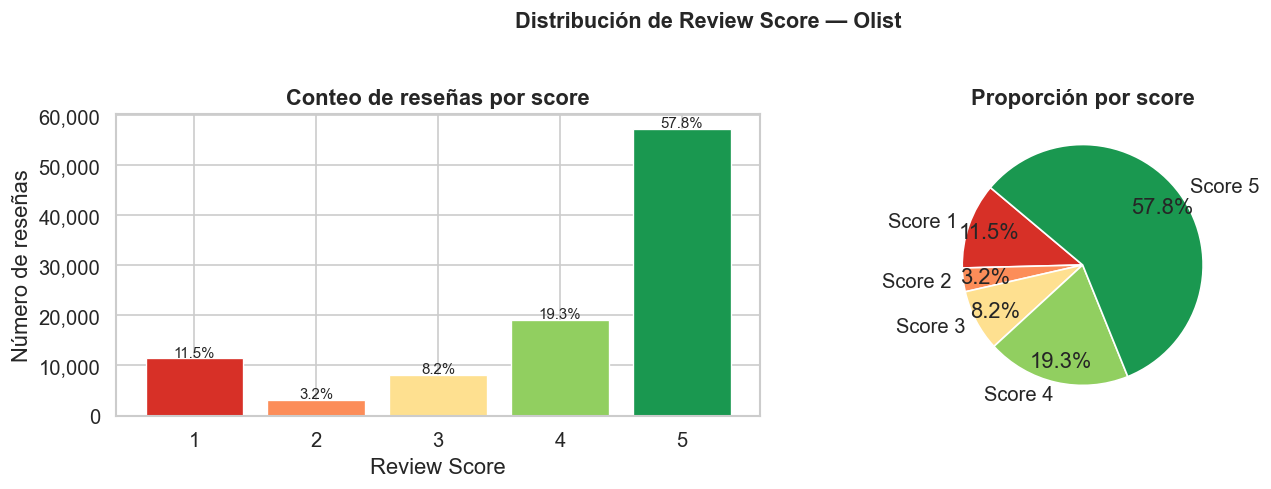


Score medio: 4.09
Score mediano: 5
% scores negativos (1-2): 14.7%


In [4]:
reviews = dfs["order_reviews"]
score_counts = reviews["review_score"].value_counts().sort_index()
score_pct = (score_counts / score_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Conteo de reseñas por score", fontweight="bold")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Número de reseñas")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for i, (v, p) in enumerate(zip(score_counts.values, score_pct.values)):
    axes[0].text(i + 1, v + 300, f"{p}%", ha="center", fontsize=9)

# Pie
axes[1].pie(
    score_counts.values,
    labels=[f"Score {i}" for i in score_counts.index],
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82,
)
axes[1].set_title("Proporción por score", fontweight="bold")

plt.suptitle("Distribución de Review Score — Olist", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "review_score_dist.png", bbox_inches="tight")
plt.show()

print(f"\nScore medio: {reviews['review_score'].mean():.2f}")
print(f"Score mediano: {reviews['review_score'].median():.0f}")
print(f"% scores negativos (1-2): {score_pct[[1,2]].sum():.1f}%")

### 3.2 Distribución de `payment_value`
Analizamos el valor total de los pagos. Se espera una distribución log-normal: muchos pedidos de bajo valor y una cola larga de pedidos costosos.

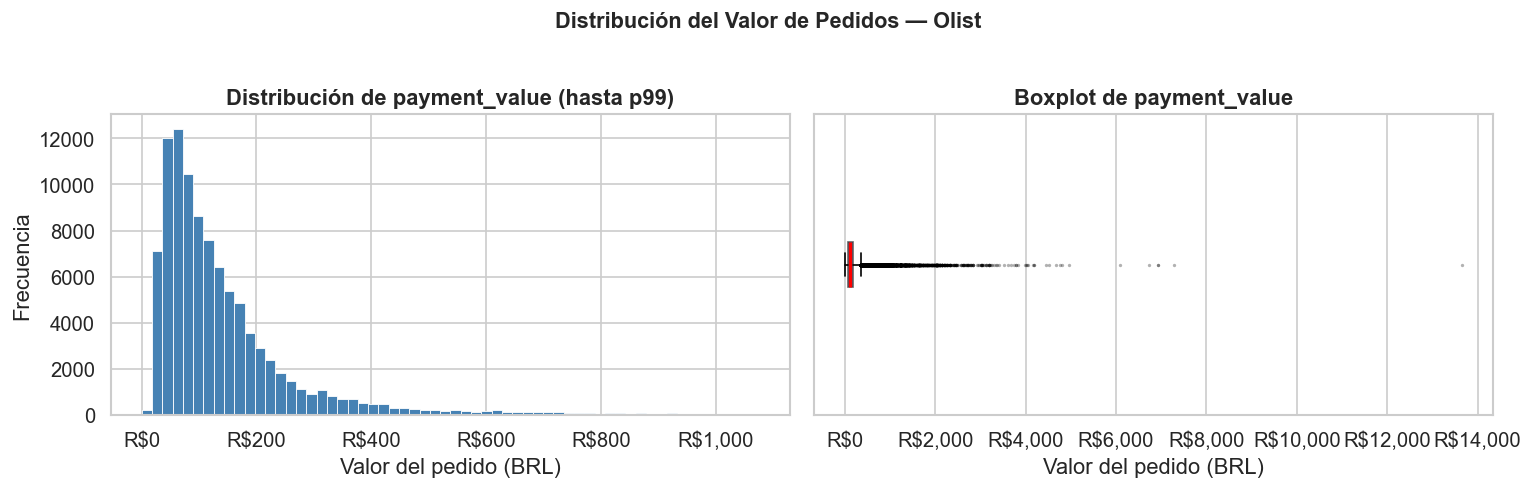

count    R$ 99,440.00
mean        R$ 160.99
std         R$ 221.95
min           R$ 0.00
25%          R$ 62.01
50%         R$ 105.29
75%         R$ 176.97
90%         R$ 308.24
95%         R$ 452.99
99%       R$ 1,075.79
max      R$ 13,664.08
Name: payment_value, dtype: object


In [5]:
payments = dfs["order_payments"]
# Agrupamos por pedido para obtener el valor total (puede haber múltiples métodos de pago)
order_payment_total = payments.groupby("order_id")["payment_value"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma (escala original, sin outliers extremos para mejor visualización)
p99 = order_payment_total.quantile(0.99)
clipped = order_payment_total[order_payment_total <= p99]
axes[0].hist(clipped, bins=60, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribución de payment_value (hasta p99)", fontweight="bold")
axes[0].set_xlabel("Valor del pedido (BRL)")
axes[0].set_ylabel("Frecuencia")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

# Boxplot
axes[1].boxplot(
    order_payment_total,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="red", linewidth=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
)
axes[1].set_title("Boxplot de payment_value", fontweight="bold")
axes[1].set_xlabel("Valor del pedido (BRL)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
axes[1].set_yticks([])

plt.suptitle("Distribución del Valor de Pedidos — Olist", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "payment_value_dist.png", bbox_inches="tight")
plt.show()

stats = order_payment_total.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(stats.apply(lambda x: f"R$ {x:,.2f}"))

### 3.3 Distribución de `order_status`
El estado del pedido refleja el ciclo de vida completo. Los pedidos `delivered` son el núcleo del análisis; los demás estados (cancelados, no entregados) son casos especiales que impactan la satisfacción del cliente.

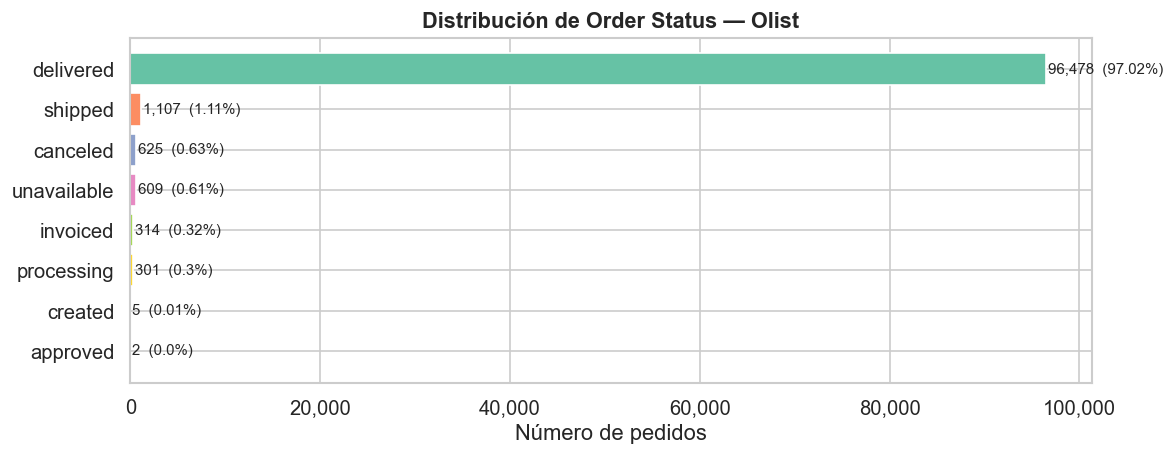


Pedidos entregados: 96,478 (97.0%)
Pedidos cancelados: 625 (0.6%)


In [6]:
orders = dfs["orders"]
status_counts = orders["order_status"].value_counts()
status_pct = (status_counts / len(orders) * 100).round(2)

palette = sns.color_palette("Set2", len(status_counts))
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(status_counts.index, status_counts.values, color=palette, edgecolor="white")
for bar, (count, pct) in zip(bars, zip(status_counts.values, status_pct.values)):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({pct}%)",
        va="center", fontsize=9,
    )

ax.set_title("Distribución de Order Status — Olist", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de pedidos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "order_status_dist.png", bbox_inches="tight")
plt.show()

print(f"\nPedidos entregados: {status_counts.get('delivered', 0):,} ({status_pct.get('delivered', 0):.1f}%)")
print(f"Pedidos cancelados: {status_counts.get('canceled', 0):,} ({status_pct.get('canceled', 0):.1f}%)")

---
## 4. Mapa de calor de correlaciones
Construimos una tabla consolidada con las variables numéricas clave a nivel de pedido y calculamos la matriz de correlación de Pearson.  
Esto nos ayuda a detectar relaciones entre satisfacción, precio, demora y método de pago antes del modelado.

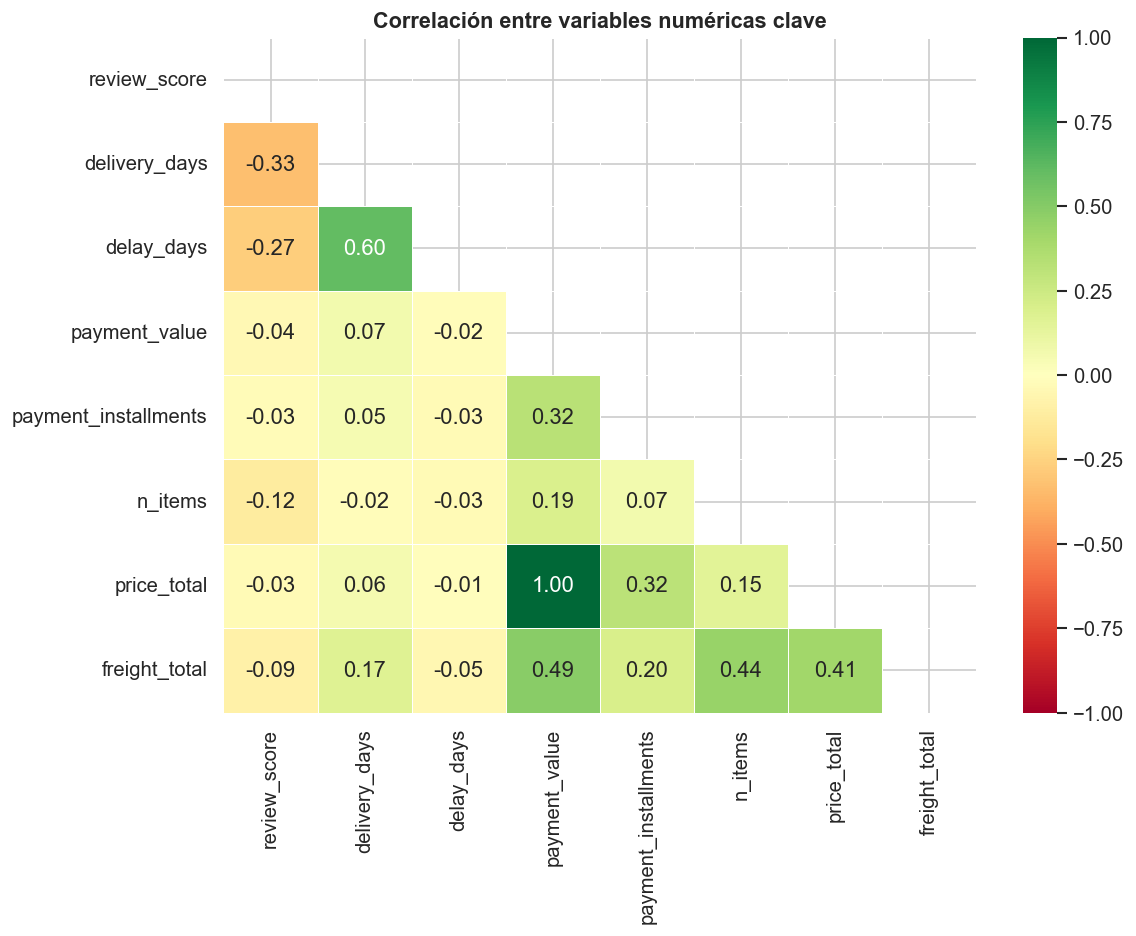


Correlación con review_score:
payment_installments   -0.030975
price_total            -0.034729
payment_value          -0.042105
freight_total          -0.089901
n_items                -0.123369
delay_days             -0.266990
delivery_days          -0.334150


In [7]:
# Convertir fechas para calcular tiempos de entrega
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days
orders["delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.days  # positivo = retraso, negativo = adelanto

# Unir con reviews y pagos
review_agg = dfs["order_reviews"].groupby("order_id")["review_score"].mean().rename("review_score")
payment_agg = dfs["order_payments"].groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
)
items_agg = dfs["order_items"].groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    price_total=("price", "sum"),
    freight_total=("freight_value", "sum"),
)

analysis_df = (
    orders[["order_id", "delivery_days", "delay_days"]]
    .join(review_agg, on="order_id")
    .join(payment_agg, on="order_id")
    .join(items_agg, on="order_id")
    .dropna(subset=["review_score", "delivery_days"])
)

num_cols = ["review_score", "delivery_days", "delay_days",
            "payment_value", "payment_installments", "n_items",
            "price_total", "freight_total"]

corr = analysis_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlación entre variables numéricas clave", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Correlaciones con review_score, ordenadas
print("\nCorrelación con review_score:")
print(corr["review_score"].drop("review_score").sort_values(ascending=False).to_string())

**Interpretación:** La variable `delay_days` (retraso vs. fecha estimada) debería mostrar la correlación negativa más fuerte con `review_score` — un retraso penaliza directamente la satisfacción del cliente. Esto motivará la ingeniería de features en la Fase 3.

---
## 5. Top 10 categorías por volumen de pedidos
Identificamos qué categorías de productos generan más pedidos. Esto orienta qué segmentos de clientes son más relevantes y qué categorías priorizar en el análisis de satisfacción.

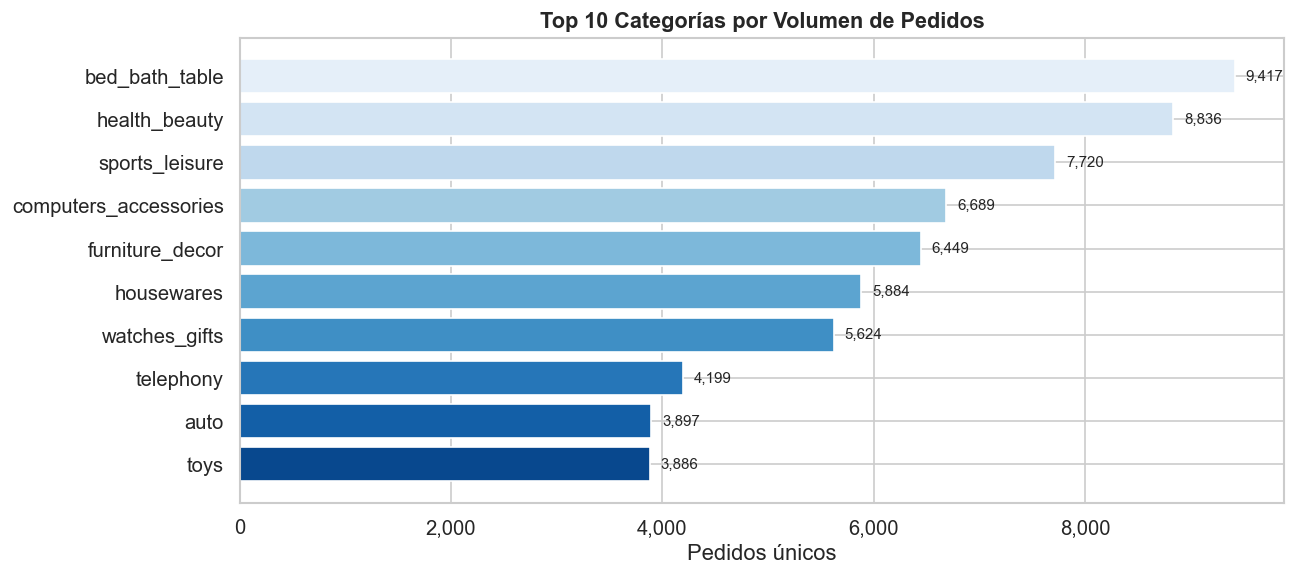

category_en
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886


In [8]:
# Unir order_items -> products -> category_translation
items = dfs["order_items"].copy()
products = dfs["products"][["product_id", "product_category_name"]].copy()
translation = dfs["category_translation"].rename(
    columns={"product_category_name": "product_category_name",
             "product_category_name_english": "category_en"}
)

items_cat = (
    items
    .merge(products, on="product_id", how="left")
    .merge(translation, on="product_category_name", how="left")
)

# Top 10 por número de pedidos únicos
top10 = (
    items_cat
    .dropna(subset=["category_en"])
    .groupby("category_en")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
palette_top = sns.color_palette("Blues_r", len(top10))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=palette_top, edgecolor="white")

for bar, val in zip(bars, top10.values[::-1]):
    ax.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center", fontsize=9,
    )

ax.set_title("Top 10 Categorías por Volumen de Pedidos", fontsize=13, fontweight="bold")
ax.set_xlabel("Pedidos únicos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "top10_categories.png", bbox_inches="tight")
plt.show()

print(top10.to_string())

---
## 6. Rango de fechas del dataset
Verificamos el período temporal cubierto por el dataset y la distribución mensual de pedidos para detectar tendencias de crecimiento o estacionalidad.

In [9]:
# Rango temporal
t_min = orders["order_purchase_timestamp"].min()
t_max = orders["order_purchase_timestamp"].max()
print(f"Primer pedido:  {t_min}")
print(f"Último pedido:  {t_max}")
print(f"Duración total: {(t_max - t_min).days} días ({(t_max - t_min).days / 365:.1f} años)")

Primer pedido:  2016-09-04 21:15:19
Último pedido:  2018-10-17 17:30:18
Duración total: 772 días (2.1 años)


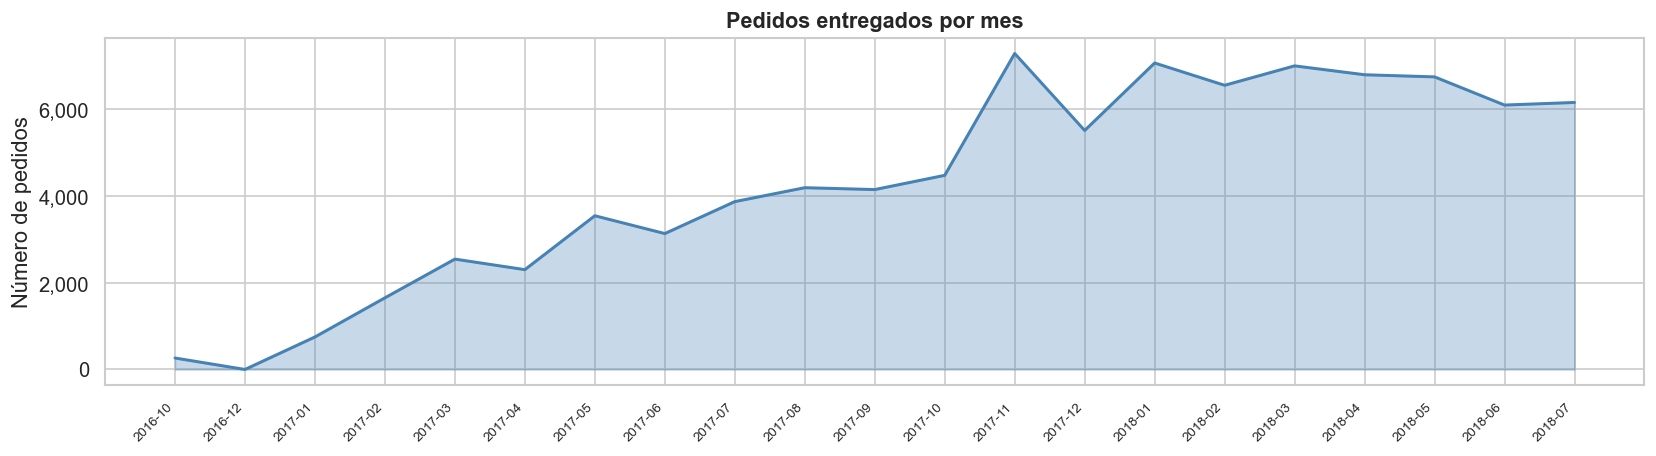


Mes con más pedidos: 2017-11 (7,289)
Mes con menos pedidos: 2016-12 (1)


In [10]:
# Pedidos por mes
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
monthly = (
    orders[orders["order_status"] == "delivered"]
    .groupby("year_month")["order_id"]
    .count()
)

# Excluir primer y último mes (datos incompletos)
monthly = monthly.iloc[1:-1]

fig, ax = plt.subplots(figsize=(14, 4))
x = range(len(monthly))
ax.fill_between(x, monthly.values, alpha=0.3, color="steelblue")
ax.plot(x, monthly.values, color="steelblue", linewidth=1.8)

ax.set_xticks(x)
ax.set_xticklabels(
    [str(p) for p in monthly.index],
    rotation=45, ha="right", fontsize=8,
)
ax.set_title("Pedidos entregados por mes", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de pedidos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "monthly_orders.png", bbox_inches="tight")
plt.show()

print(f"\nMes con más pedidos: {monthly.idxmax()} ({monthly.max():,})")
print(f"Mes con menos pedidos: {monthly.idxmin()} ({monthly.min():,})")

---
## 7. Resumen de hallazgos — Data Understanding

| Dimensión | Hallazgo clave |
|-----------|----------------|
| **Volumen** | ~99K pedidos, ~112K ítems, ~99K reseñas en ~2 años de datos |
| **Calidad** | Nulos relevantes en fechas de entrega y texto de reseñas; `geolocation` tiene duplicados por ZIP |
| **Satisfacción** | Distribución bimodal en review_score (picos en 1 y 5); sesgo positivo |
| **Valor** | payment_value con fuerte sesgo derecho; necesita transformación log para modelado |
| **Estado** | >96% pedidos entregados; cancelaciones son minoría pero impactan satisfacción |
| **Correlación** | Delay vs. delivery time se esperan como mejores predictores de review_score |
| **Categorías** | bed_bath_table, health_beauty y sports_leisure lideran en volumen |
| **Temporalidad** | Crecimiento sostenido con pico en Nov 2017 (Black Friday Brasil) |

### Próximos pasos — Fase 3 (Data Preparation)
- Parsear columnas de fecha y calcular `delivery_days` y `delay_days`
- Tratar nulos en `order_delivered_customer_date` (filtrar solo `delivered`)
- Traducir categorías a inglés y tratar las sin categoría
- Construir tabla maestra a nivel `order_id` para modelado
- Calcular métricas RFM por cliente